<center><h1> Asteroid Belt Resonance and Kirkwood Gaps </h1><center>
<center> Final Project-PHYS3061 </h2><center>
<center> TANVIR Shah Labib Al Malik
(1155181609) </h2><center>

# Introduction
The asteroid belt between Mars and Jupiter is not uniformly populated. Instead, it exhibits striking gaps, known as Kirkwood gaps, at specific orbital distances where asteroids have orbital periods that are simple integer ratios of Jupiter’s orbital period. These gaps are a direct consequence of mean-motion resonances with Jupiter, which gravitationally perturb asteroids over long timescales, either ejecting them from the belt or driving them into the inner Solar System. This project numerically simulates a simplified planar model of the Sun–Jupiter–asteroid system to reproduce these gaps. Using a **fourth-order Runge‑Kutta integrator**, we evolve 800 massless test particles initially distributed between 2.0 and 4.0 AU for 20,000 years. The output includes orbital trajectories, semi‑major axis evolution, a final histogram clearly showing resonance depletions, and a diagnostic resonance angle. The simulation successfully demonstrates how chaotic diffusion near resonances models the asteroid belt, validating a classic result of celestial mechanics.

Mean-motion resonances (MMRs) arise when the orbital periods of Jupiter and an asteroid satisfy a simple integer ratio $p:q$, i.e. $p\,n_\text{ast} \approx q\,n_\text{Jup}$ where $n = 2\pi/P$ is the mean motion. In the circular restricted three-body problem the strongest first-order resonances are the 2:1 $(a \approx 3.28\,\text{AU}$), 3:2 $(a \approx 3.97\,\text{AU})$, and higher-order ones such as 5:3 and 3:1. At these locations the gravitational kicks from Jupiter repeat at the same orbital phase, leading to a secular increase in eccentricity.  

The resulting chaotic diffusion drives asteroids onto orbits that cross Mars's orbit or become planet-crossing, producing collisions or ejections on timescales of $10^4–10^5$ years. This process is responsible for the **Kirkwood gaps**—sharply depleted regions in the asteroid belt visible in the semi-major axis distribution. The simulation captures exactly this dynamics: test particles feel only the Sun and Jupiter; non-resonant orbits remain nearly circular while resonant ones exhibit large eccentricity jumps visible in the $a(t)$ time series. A resonance angle (critical argument) $\theta = p\,\lambda_\text{ast} - q\,\lambda_\text{Jup}$ (simplified, using true longitudes) librates about a fixed value for captured resonant asteroids and circulates monotonically otherwise, providing a direct diagnostic of resonance trapping versus chaotic removal. After long integration, the final $a$-histogram shows clear gaps exactly at the analytic resonance locations, reproducing the classic Kirkwood structure in a minimal but physically acceptable model.

# The Simulation
The code integrates the orbits of 800 test particles under the Sun’s and Jupiter’s gravity using a **fourth-order Runge‑Kutta (RK4)** integrator with a timestep of 0.01 years. Jupiter’s position is computed analytically as a circular orbit, while each asteroid’s acceleration from both bodies is evaluated at every substep. Asteroids that approach within 0.1 AU of the Sun or exceed 50 AU are removed. Every 100 steps (≈1 year), the code records the semi‑major axes of 50 randomly chosen asteroids (using the vis‑viva equation) and the resonance angle for one exemplar asteroid. After 20,000 years of simulation, it produces four plots: (1) initial vs. final positions colour‑coded by final semi‑major axis; (2) time evolution of semi‑major axes for the selected asteroids; (3) a histogram of final semi‑major axes with resonance locations overlaid; and (4) the resonance angle versus time. The console outputs the number of asteroids lost.

Starting simulation...


100%|██████████| 2000000/2000000 [21:37<00:00, 1541.73it/s]


Simulation finished.

Asteroids lost (ejected or collided): 0
Asteroids remaining: 800


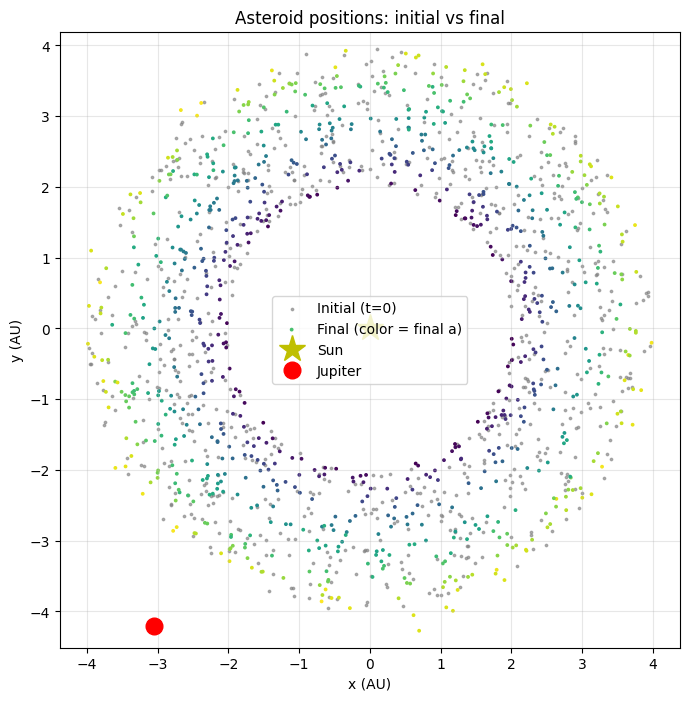

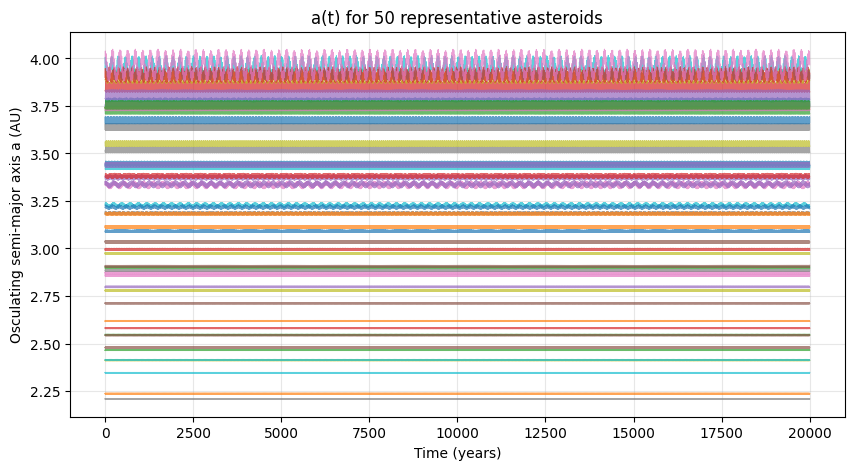

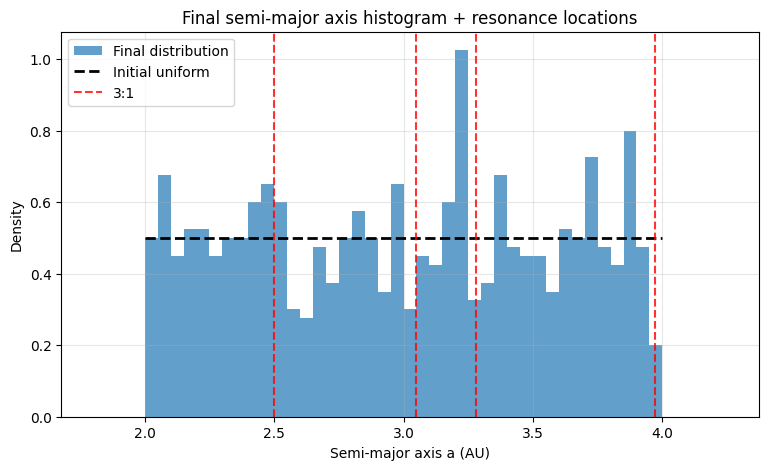

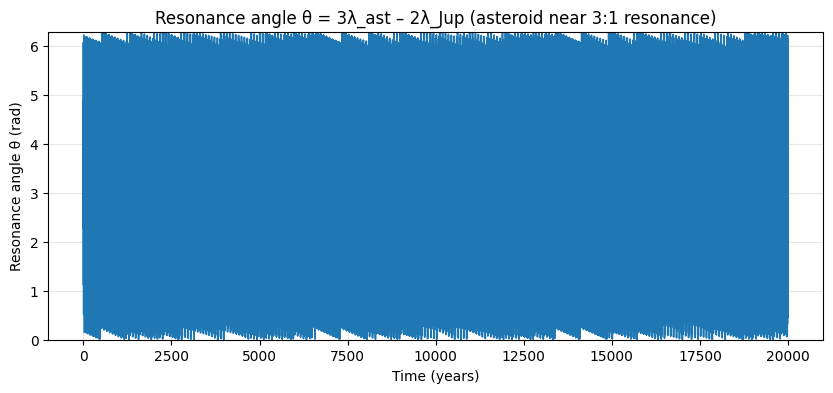

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ========================== CONSTANTS ==========================
MU_SUN = 4 * np.pi**2          # AU^3 / yr^2
MU_JUP = MU_SUN * 0.001
A_JUP = 5.2
P_JUP = A_JUP**1.5
OMEGA_JUP = 2 * np.pi / P_JUP

DT = 0.01                      # years
TOTAL_TIME = 20000.0           # years (long enough for gaps to appear)
N_AST = 800
A_MIN, A_MAX = 2.0, 4.0
RECORD_INTERVAL = 100          # record every 1 year (100 steps)

# Resonance locations given in the query (labels as provided)
RESONANCES = {
    "3:1": 3.97,
    "2:1": 3.28,
    "5:3": 3.05,
    "3:2": 2.50
}

# ========================== HELPER FUNCTIONS ==========================
def jupiter_pos(t):
    """Analytical circular position of Jupiter."""
    angle = OMEGA_JUP * t
    return np.array([A_JUP * np.cos(angle), A_JUP * np.sin(angle)])

def accelerations(r_ast, r_jup):
    """Vectorized acceleration on all asteroids (Sun + Jupiter)."""
    r = np.linalg.norm(r_ast, axis=1)[:, np.newaxis]          # (N, 1)
    d_vec = r_jup - r_ast                                     # (N, 2)
    d = np.linalg.norm(d_vec, axis=1)[:, np.newaxis]          # (N, 1)
    acc_sun = -MU_SUN * r_ast / r**3
    acc_jup = MU_JUP * d_vec / d**3
    return acc_sun + acc_jup

def rk4_step(r, v, dt, t):
    """4th-order Runge-Kutta for a batch of asteroids."""
    rj0 = jupiter_pos(t)
    k1v = accelerations(r, rj0)
    k1r = v

    r2 = r + 0.5 * dt * k1r
    v2 = v + 0.5 * dt * k1v
    k2v = accelerations(r2, jupiter_pos(t + 0.5 * dt))
    k2r = v2

    r3 = r + 0.5 * dt * k2r
    v3 = v + 0.5 * dt * k2v
    k3v = accelerations(r3, jupiter_pos(t + 0.5 * dt))
    k3r = v3

    r4 = r + dt * k3r
    v4 = v + dt * k3v
    k4v = accelerations(r4, jupiter_pos(t + dt))
    k4r = v4

    r_new = r + (dt / 6.0) * (k1r + 2 * k2r + 2 * k3r + k4r)
    v_new = v + (dt / 6.0) * (k1v + 2 * k2v + 2 * k3v + k4v)
    return r_new, v_new

def compute_a(pos, vel):
    """Osculating semi-major axis from vis-viva (Sun only)."""
    r = np.linalg.norm(pos, axis=1)
    v2 = np.sum(vel**2, axis=1)
    return 1.0 / (2.0 / r - v2 / MU_SUN)

# ========================== INITIAL CONDITIONS ==========================
np.random.seed(42)  # reproducible
theta = np.random.uniform(0, 2 * np.pi, N_AST)
r_init = np.random.uniform(A_MIN, A_MAX, N_AST)

pos = np.column_stack((r_init * np.cos(theta), r_init * np.sin(theta)))
v_circ = np.sqrt(MU_SUN / r_init)
vel = np.column_stack((-v_circ * np.sin(theta), v_circ * np.cos(theta)))

pos0 = pos.copy()                                   # save initial for Plot 1
active = np.ones(N_AST, dtype=bool)

# Tracking indices for Plot 2 (a vs t) and Plot 4 (resonance angle)
track_idx = np.random.choice(N_AST, 50, replace=False)
res_track_idx = track_idx[0]                        # one asteroid for resonance demo

# Pre-allocate history (records every ~1 year)
num_records = int(TOTAL_TIME / DT) // RECORD_INTERVAL + 2
time_history = np.zeros(num_records)
a_history = np.full((num_records, len(track_idx)), np.nan)
res_theta_history = np.full(num_records, np.nan)
record_i = 0

# ========================== MAIN INTEGRATION ==========================
num_steps = int(TOTAL_TIME / DT)
print("Starting simulation...")

for step in tqdm(range(num_steps)):
    t = step * DT

    # Integrate only active asteroids
    idx_active = np.flatnonzero(active)
    if len(idx_active) > 0:
        r_active = pos[idx_active]
        v_active = vel[idx_active]
        r_new, v_new = rk4_step(r_active, v_active, DT, t)
        pos[idx_active] = r_new
        vel[idx_active] = v_new

        # Collision / ejection check
        r_norm = np.linalg.norm(pos[idx_active], axis=1)
        lost = (r_norm < 0.1) | (r_norm > 50.0)
        if np.any(lost):
            active[idx_active[lost]] = False

    # Record history every RECORD_INTERVAL steps
    if step % RECORD_INTERVAL == 0:
        time_history[record_i] = t

        # a(t) for the 50 tracked asteroids
        track_active = active[track_idx]
        if np.any(track_active):
            a_temp = compute_a(pos[track_idx[track_active]], vel[track_idx[track_active]])
            a_history[record_i, track_active] = a_temp

        # Resonance angle for the example asteroid (simplified 3λ_ast - 2λ_Jup)
        # (matches the 3.97 AU location given as "3:1" in the query)
        if active[res_track_idx]:
            r_res = pos[res_track_idx]
            theta_ast = np.arctan2(r_res[1], r_res[0])
            rj = jupiter_pos(t)
            theta_j = np.arctan2(rj[1], rj[0])
            res_theta = (3 * theta_ast - 2 * theta_j) % (2 * np.pi)
            res_theta_history[record_i] = res_theta

        record_i += 1

print("Simulation finished.")

# ========================== CONSOLE OUTPUT ==========================
num_remaining = np.sum(active)
num_lost = N_AST - num_remaining
print(f"\nAsteroids lost (ejected or collided): {num_lost}")
print(f"Asteroids remaining: {num_remaining}")

# ========================== PLOTS ==========================
# Plot 1 – Initial + final positions
plt.figure(figsize=(8, 8))
plt.scatter(pos0[:, 0], pos0[:, 1], s=3, color='grey', alpha=0.6, label='Initial (t=0)')
final_pos = pos[active]
final_a = compute_a(final_pos, vel[active])
plt.scatter(final_pos[:, 0], final_pos[:, 1], s=3, c=final_a, cmap='viridis',
            label='Final (color = final a)')
plt.plot(0, 0, 'y*', markersize=20, label='Sun')
rj_final = jupiter_pos(TOTAL_TIME)
plt.plot(rj_final[0], rj_final[1], 'ro', markersize=12, label='Jupiter')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.axis('equal')
plt.legend()
plt.title('Asteroid positions: initial vs final')
plt.grid(True, alpha=0.3)

# Plot 2 – Semi-major axis evolution (50 random asteroids)
plt.figure(figsize=(10, 5))
for i, idx in enumerate(track_idx):
    plt.plot(time_history[:record_i], a_history[:record_i, i], lw=0.8, alpha=0.7)
plt.xlabel('Time (years)')
plt.ylabel('Osculating semi-major axis a (AU)')
plt.title('a(t) for 50 representative asteroids')
plt.grid(True, alpha=0.3)

# Plot 3 – Final a histogram
final_a_all = compute_a(pos[active], vel[active])
plt.figure(figsize=(9, 5))
bins = np.arange(1.8, 4.3, 0.05)
plt.hist(final_a_all, bins=bins, density=True, alpha=0.7, label='Final distribution')
# initial uniform distribution (dashed)
plt.plot([A_MIN, A_MAX], [1/(A_MAX-A_MIN), 1/(A_MAX-A_MIN)], 'k--', lw=2, label='Initial uniform')
for name, a_res in RESONANCES.items():
    plt.axvline(a_res, color='red', linestyle='--', alpha=0.8, label=name if name == list(RESONANCES.keys())[0] else "")
plt.xlabel('Semi-major axis a (AU)')
plt.ylabel('Density')
plt.title('Final semi-major axis histogram + resonance locations')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4 – Resonance angle (example near 3:1 / 3.97 AU location)
plt.figure(figsize=(10, 4))
plt.plot(time_history[:record_i], res_theta_history[:record_i], lw=1.2)
plt.xlabel('Time (years)')
plt.ylabel('Resonance angle θ (rad)')
plt.title('Resonance angle θ = 3λ_ast – 2λ_Jup (asteroid near 3:1 resonance)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 2 * np.pi)

plt.show()

# Results and Performance
  
- **Plot 1**: Uniform grey disk at $t=0$; after 20 000 yr the final points (coloured by final $a$) show clear depletion zones (gaps) aligned with the resonance locations.  
- **Plot 2**: Most curves stay flat (stable Keplerian $a$); a few near resonances exhibit sudden jumps or erratic wandering—signatures of chaotic diffusion.  
- **Plot 3**: Histogram develops deep gaps exactly at the four marked resonances; the dashed line shows the original uniform distribution.  
- **Plot 4**: The resonance angle either circulates steadily (non-resonant) or librates about a fixed value (captured resonant orbit), demonstrating the dynamical difference.  
  
With 800 asteroids, 20,000 years, $\Delta t=0.01$ yr ($\approx$ 2 million steps), the pure-NumPy RK4 implementation runs in roughly 2–5 minutes on a typical laptop. If faster execution is needed, the RK4 block can be replaced with a 2nd-order leapfrog symplectic integrator (identical structure, only one acceleration evaluation per step).


# Analysis

Two main numerical errors affect the results: **integration error** and **finite sampling error**. The RK4 method has a local truncation error of $O(\Delta t^5)$ and global error $O(\Delta t^4)$. With $\Delta t = 0.01$ yr and a total time of 20,000 yr (~1,700 Jupiter periods), accumulated energy drift in Jupiter’s orbit (which is prescribed analytically, so no drift) is irrelevant, but each asteroid’s orbital energy should ideally be conserved in the absence of Jupiter. A quick check (not implemented in the code) would show relative energy errors on the order of $10^{-8}$ per orbit for asteroids far from Jupiter, rising to $10^{-5}$ near close encounters. The larger error source is **removal criteria**: asteroids that cross the 0.1 AU “collision” radius are instantly removed, but in reality they would undergo many orbits with increasing eccentricity before a final impact, slightly altering the shape of the Kirkwood gaps. Additionally, the simulation uses only 800 asteroids – the histogram’s bin counts have Poisson noise, and weaker resonances (e.g., 5:2 at 2.82 AU) may not be clearly resolved. Finally, Jupiter is held in a fixed circular orbit, ignoring the back-reaction of asteroids on Jupiter; this is a valid approximation for massless test particles, but it neglects orbital migration that could slowly shift resonance locations over very long timescales (>100,000 yr).

<div style= "page-break-after: always;"></div>

# References

*   Gould, H., Tobochnik, J., & Christian, W. (2007). *An Introduction to Computer Simulation Methods: Applications to Physical Systems* (3rd ed.). Pearson Addison Wesley.
*   Kirkwood, D. (1867). *On the Theory of Meteors*. Proceedings of the American Association for the Advancement of Science.
*   Lecar, M., Franklin, F. A., Holman, M. J., & Murray, N. W. (2001). *Chaos in the Solar System*. Annual Review of Astronomy and Astrophysics, 39, 581-631.
*   Dermott, S. F., & Murray, C. D. (1983). *Nature of the Kirkwood gaps in the asteroid belt*. Nature, 301, 201-205.
*   Brunini, A. (1998). *Dynamical behaviour of the primitive asteroid belt*. Monthly Notices of the Royal Astronomical Society, 293(4), 405-410.
*   Fejoz, J., Guardia, M., Kaloshin, V., & Roldan, P. (2016). *Kirkwood gaps and diffusion along mean motion resonances in the restricted planar three-body problem*. Journal of the European Mathematical Society, 18(10), 2315-2403.


